In [1]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from weightedtraining.instancepipeline1s import get_data_loaders
from weightedtraining.finaltrain1s import EarthquakeCNN, evaluate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = PROJECT_ROOT / "weightedtraining" / "data" / "best_model_1s.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model = EarthquakeCNN().to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()




Train samples: 979487
Validation samples: 96993
Test samples: 82769
Train batches: 7653
Val batches: 758
Test batches: 647
Train samples: 979487
Validation samples: 96993
Test samples: 82769
Train batches: 7653
Val batches: 758
Test batches: 647


EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [4]:
import torch
import numpy as np
import pandas as pd
TARGET_MEAN = 2.28802128052746
train_loader, val_loader, test_loader = get_data_loaders()
all_predictions = []
all_targets = []
model.eval()
with torch.no_grad():
    for waveforms,magnitudes in test_loader:
        waveforms,magnitudes = waveforms.to(device), magnitudes.to(device)
        predictions = model(waveforms).squeeze(-1) 
        magnitudes = magnitudes + TARGET_MEAN
        predictions = predictions + TARGET_MEAN
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())
results = pd.DataFrame({
    "true_magnitude": np.array(all_targets),
    "predicted_magnitude": np.array(all_predictions)
})


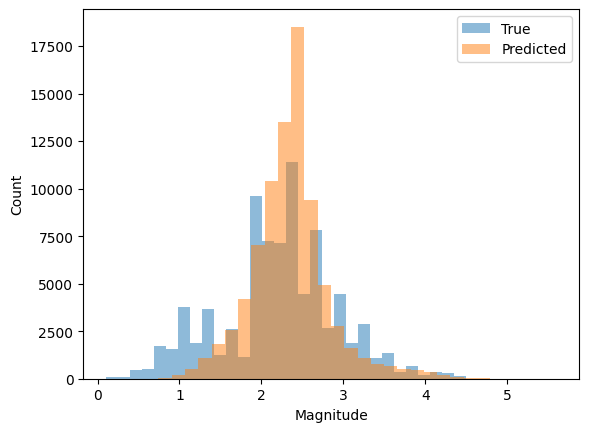

In [5]:
import matplotlib.pyplot as plt

plt.hist(results["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [11]:
results["error"] = (
    results["predicted_magnitude"]
    - results["true_magnitude"]
)

results["bin"] = pd.cut(
    results["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6],
    right=False
)

results.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"[0, 1)",4443,1.151740,1.155189
"[1, 2)",15919,0.610629,0.603685
"[2, 3)",51082,0.046903,0.046106
"[3, 4)",10339,-0.489229,-0.550071
"[4, 5)",986,-0.780391,-0.718203


In [12]:
results["error"] = (
    results["predicted_magnitude"] -
    results["true_magnitude"]
)
for low in range(6):
    mask = (
        (results["true_magnitude"] >= low) &
        (results["true_magnitude"] < low + 1)
    )

    print(
        f"{low}-{low+1}",
        "count =", mask.sum(),
        "MAE =", results.loc[mask, "error"].abs().mean(),
        "bias =", results.loc[mask, "error"].mean()
    )

0-1 count = 4443 MAE = 1.1518333 bias = 1.1517404
1-2 count = 15919 MAE = 0.6320637 bias = 0.610629
2-3 count = 51082 MAE = 0.28930944 bias = 0.046902534
3-4 count = 10339 MAE = 0.6060504 bias = -0.4892291
4-5 count = 986 MAE = 0.84912044 bias = -0.7803909
5-6 count = 0 MAE = nan bias = nan


In [8]:
results.to_csv("1sregular.csv")